# IT24101008 — Data Preprocessing & EDA (Fetal Health CTG)

**Student ID:** `IT24101008`  
**Email:** `it24101008@my.sliit.lk`  
**Module:** IT2011 Artificial Intelligence and Machine Learning  
**Notebook focus:** Mode/Median Impute, IQR+Log Transform, OrdinalEncode & SelectFromModel

### Important (Progress Review I)
This notebook covers **all required technique categories** (missing data, encoding, outliers, scaling, feature engineering/selection/dimension reduction) plus ≥3 EDA plots.
Method *choices inside each category* differ from other group members.

### Problem framing
Multiclass classification of fetal health from CTG features: **Normal (1)**, **Suspect (2)**, **Pathological (3)**.


## 0. Setup and paths


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler,
    LabelEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import (
    SelectKBest, mutual_info_classif, chi2, VarianceThreshold, SelectFromModel
)
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)

ROOT = Path('..').resolve()
RAW_CSV = ROOT / 'data' / 'raw' / 'fetal_health.csv'
FIG_DIR = ROOT / 'results' / 'eda_visualizations' / 'IT24101008'
OUT_DIR = ROOT / 'results' / 'outputs'
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'fetal_health'
CLASS_MAP = {1.0: 'Normal', 2.0: 'Suspect', 3.0: 'Pathological'}
RANDOM_STATE = 42
STUDENT_ID = 'IT24101008'

print('Student:', STUDENT_ID)
print('RAW_CSV exists:', RAW_CSV.exists())
print('Figures ->', FIG_DIR)


Student: IT24101008
RAW_CSV exists: True
Figures -> /home/neon-cultivator/us2/project-aiml/results/eda_visualizations/IT24101008


## 1. Load and understand the dataset

**What:** Load CTG data; inspect shape, dtypes, class balance.  
**Why:** Preprocessing choices must follow the real data profile.


In [2]:
df = pd.read_csv(RAW_CSV)
print('Shape:', df.shape)
print('\nDtypes:\n', df.dtypes)
display(df.head())
display(df.describe().T)
counts = df[TARGET].value_counts().sort_index()
print('\nTarget value counts:')
display(counts.rename(index=CLASS_MAP))
print('Class proportions (%):')
display((100 * counts / len(df)).round(2).rename(index=CLASS_MAP))


Shape: (2126, 22)

Dtypes:
 baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                       

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000



Target value counts:


fetal_health
Normal          1655
Suspect          295
Pathological     176
Name: count, dtype: int64

Class proportions (%):


fetal_health
Normal          77.85
Suspect         13.88
Pathological     8.28
Name: count, dtype: float64

**Interpretation:** Strong Normal-class dominance means later metrics should emphasise macro-F1 / per-class recall.


## 2. Handling missing data — Median + mode

**What:** Median for continuous CTG measures; most-frequent for `histogram_tendency`.  
**Why:** Median resists skew; mode suits discrete ordinal tendency.


In [3]:
missing = df.isna().sum()
display(pd.DataFrame({'missing_count': missing, 'missing_pct': (100 * missing / len(df)).round(2)}))
print('Total missing cells:', int(df.isna().sum().sum()))
feature_cols = [c for c in df.columns if c != TARGET]
cont_cols = [c for c in feature_cols if c != 'histogram_tendency']
df_imputed = df.copy()
med_imp = SimpleImputer(strategy='median')
mode_imp = SimpleImputer(strategy='most_frequent')
df_imputed[cont_cols] = med_imp.fit_transform(df[cont_cols])
df_imputed[['histogram_tendency']] = mode_imp.fit_transform(df[['histogram_tendency']])
print('After median/mode imputation — missing cells:', int(df_imputed.isna().sum().sum()))


,missing_count,missing_pct
baseline value,0,0.0
accelerations,0,0.0
fetal_movement,0,0.0
uterine_contractions,0,0.0
light_decelerations,0,0.0
severe_decelerations,0,0.0
prolongued_decelerations,0,0.0
abnormal_short_term_variability,0,0.0
mean_value_of_short_term_variability,0,0.0
percentage_of_time_with_abnormal_long_term_variability,0,0.0


Total missing cells: 0
After median/mode imputation — missing cells: 0


**Interpretation:** Mixed strategy matches feature types even though this file currently has zero missing values.


## 3. Duplicates and basic quality


In [4]:
n_dupes = df_imputed.duplicated().sum()
print('Exact duplicate rows:', int(n_dupes))
df_clean = df_imputed.drop_duplicates().copy()
print('Shape after dropping duplicates:', df_clean.shape)
print('Rows removed:', len(df_imputed) - len(df_clean))
feature_cols = [c for c in df_clean.columns if c != TARGET]


Exact duplicate rows: 13
Shape after dropping duplicates: (2113, 22)
Rows removed: 13


**Interpretation:** Exact duplicates are removed so repeated CTG rows do not inflate class counts.


## 4. Exploratory Data Analysis (≥3 visualizations)


### 4.1 Class distribution


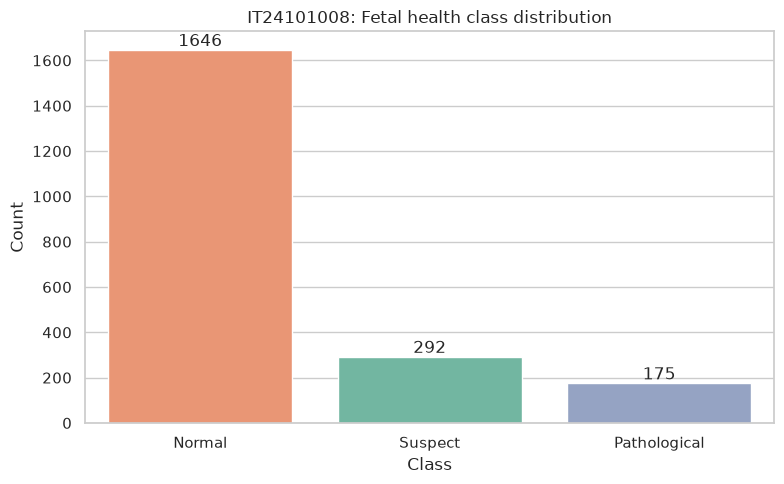

In [5]:
plot_df = df_clean.copy()
plot_df['class_name'] = plot_df[TARGET].map(CLASS_MAP)
order = ['Normal', 'Suspect', 'Pathological']
fig, ax = plt.subplots()
sns.countplot(data=plot_df, x='class_name', order=order, hue='class_name', palette='Set2', legend=False, ax=ax)
ax.set_title(f'{STUDENT_ID}: Fetal health class distribution')
ax.set_xlabel('Class'); ax.set_ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
fig.tight_layout()
fig.savefig(FIG_DIR / '01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Normal dominates; minority Suspect/Pathological classes need careful evaluation later.


### 4.2 Boxplots by class


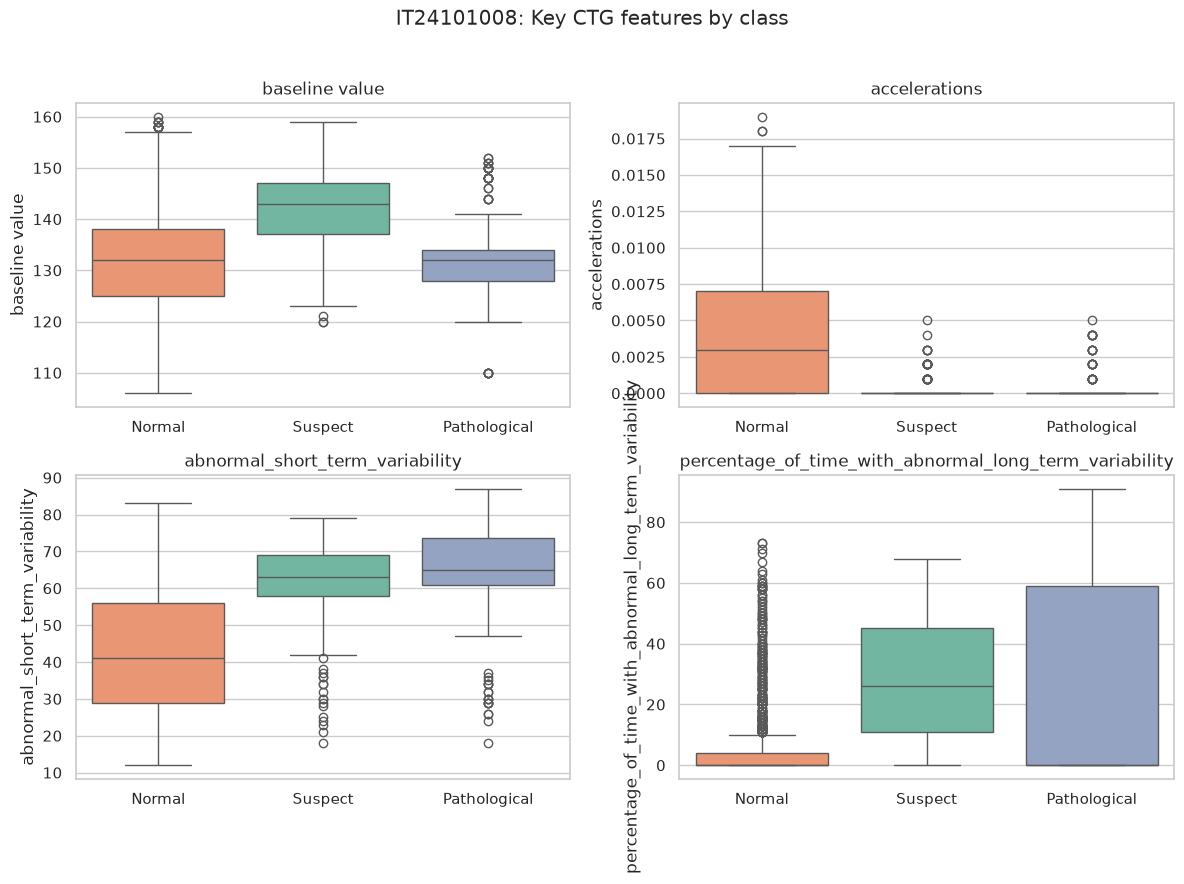

In [6]:
box_features = [
    'baseline value', 'accelerations',
    'abnormal_short_term_variability',
    'percentage_of_time_with_abnormal_long_term_variability',
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), box_features):
    sns.boxplot(data=plot_df, x='class_name', y=col, order=order, hue='class_name', palette='Set2', legend=False, ax=ax)
    ax.set_title(col); ax.set_xlabel('')
fig.suptitle(f'{STUDENT_ID}: Key CTG features by class', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / '02_boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Variability and acceleration patterns differ across health classes.


### 4.3 Correlation heatmap


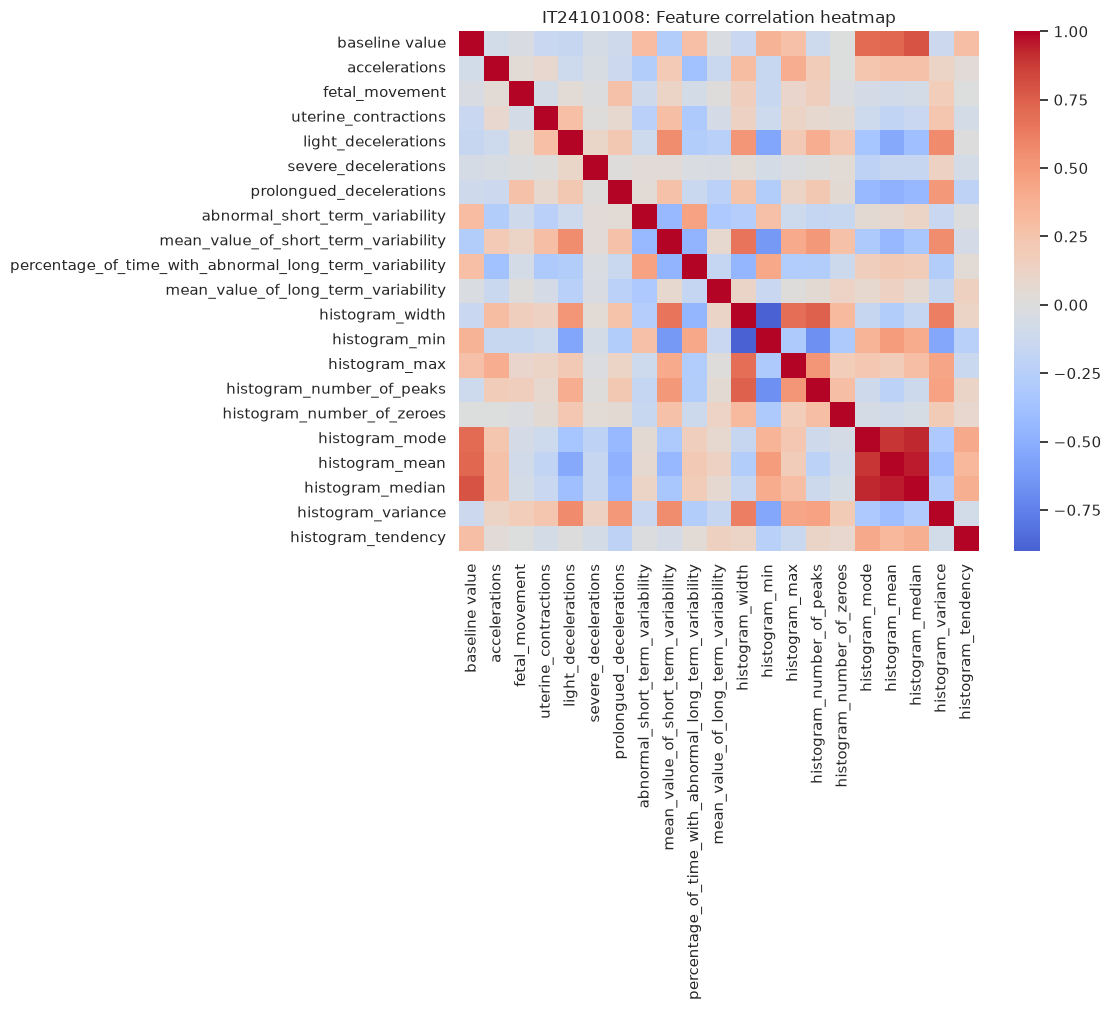

Top 10 |correlation| pairs:


histogram_mean   histogram_median             0.948077
histogram_mode   histogram_median             0.933166
histogram_width  histogram_min                0.899054
histogram_mode   histogram_mean               0.893083
baseline value   histogram_median             0.788487
histogram_width  histogram_number_of_peaks    0.746894
baseline value   histogram_mean               0.722152
                 histogram_mode               0.708074
histogram_width  histogram_max                0.692645
histogram_min    histogram_number_of_peaks    0.670410
dtype: float64

In [7]:
corr = df_clean[feature_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title(f'{STUDENT_ID}: Feature correlation heatmap')
fig.tight_layout()
fig.savefig(FIG_DIR / '03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().abs().sort_values(ascending=False)
print('Top 10 |correlation| pairs:')
display(corr_pairs.head(10))


**Interpretation:** Histogram features are highly correlated → selection / dimension reduction is justified.


## 5. Outlier handling — IQR capping + log1p skew transform

**What:** Cap with IQR, then `log1p` on skewed CTG rate features.  
**Why:** Caps spikes and compresses skew before scaling/PCA.


In [8]:
df_out = df_clean.copy()
outlier_cols = [c for c in feature_cols if c != 'histogram_tendency']
report = []
for col in outlier_cols:
    q1, q3 = df_out[col].quantile(0.25), df_out[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df_out[col] < lower) | (df_out[col] > upper)).sum())
    df_out[col] = df_out[col].clip(lower, upper)
    report.append({'feature': col, 'n_outliers': n_out})
skew_cols = ['accelerations', 'fetal_movement', 'light_decelerations', 'histogram_variance']
for col in skew_cols:
    shifted = df_out[col] - df_out[col].min()
    df_out[col] = np.log1p(shifted)
display(pd.DataFrame(report).sort_values('n_outliers', ascending=False).head(10))
print('Applied log1p to:', skew_cols)
print('Rows retained:', len(df_out))


,feature,n_outliers
15,histogram_number_of_zeroes,502
2,fetal_movement,305
9,percentage_of_time_with_abnormal_long_term_var...,305
19,histogram_variance,184
6,prolongued_decelerations,178
4,light_decelerations,150
16,histogram_mode,73
10,mean_value_of_long_term_variability,71
8,mean_value_of_short_term_variability,70
17,histogram_mean,45


Applied log1p to: ['accelerations', 'fetal_movement', 'light_decelerations', 'histogram_variance']
Rows retained: 2113


**Interpretation:** Outlier treatment documents the clinical trade-off between noise reduction and minority-class preservation.


## 6. Encoding — OrdinalEncoder tendency + LabelEncoder target

**What:** Preserve ordered tendency levels with `OrdinalEncoder`.  
**Why:** Tendency naturally orders as -1 < 0 < 1.


In [9]:
df_enc = df_out.copy()
ord_enc = OrdinalEncoder(categories=[[-1.0, 0.0, 1.0]])
df_enc['histogram_tendency_ord'] = ord_enc.fit_transform(df_enc[['histogram_tendency']])
label_encoder = LabelEncoder()
df_enc['fetal_health_encoded'] = label_encoder.fit_transform(df_enc[TARGET].astype(int))
display(df_enc[['histogram_tendency', 'histogram_tendency_ord']].drop_duplicates().sort_values('histogram_tendency'))
print('Target mapping:', dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
extra_enc_cols = ['histogram_tendency_ord']


,histogram_tendency,histogram_tendency_ord
22,-1.0,0.0
1,0.0,1.0
0,1.0,2.0


Target mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2)}


**Interpretation:** Encoding makes categorical/ordinal fields explicit for sklearn estimators.


## 7–8. Scaling (Z-score standardization), feature engineering, selection, dimension reduction


,count,mean,std,min,25%,50%,75%,max
ctg_risk_index,2113.0,53.624941,23.704941,12.000000,34.000000,53.000000,67.000000,114.500000
accel_minus_decel,2113.0,0.001425,0.004770,-0.007472,0.000000,0.000000,0.003992,0.014889
ltv_stv_ratio,2113.0,8.880263,6.791644,0.000000,3.695651,7.759997,12.818170,36.499818
hist_asymmetry,2113.0,4.683625,5.588169,0.000000,1.000000,2.500000,6.000000,38.000000


Scaler: StandardScaler
Scaled mean sample: {'baseline value': -0.0, 'accelerations': -0.0, 'fetal_movement': 0.0}


SelectFromModel(RandomForest) features:


/home/neon-cultivator/us2/project-aiml/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


,feature,importance
17,histogram_mean,0.113120
7,abnormal_short_term_variability,0.104831
21,ctg_risk_index,0.098514
18,histogram_median,0.087170
10,mean_value_of_long_term_variability,0.063932
16,histogram_mode,0.057768
9,percentage_of_time_with_abnormal_long_term_var...,0.056800
1,accelerations,0.053910
8,mean_value_of_short_term_variability,0.053310
23,ltv_stv_ratio,0.049564


PCA components for target variance: 9
Cumulative variance: 0.9137


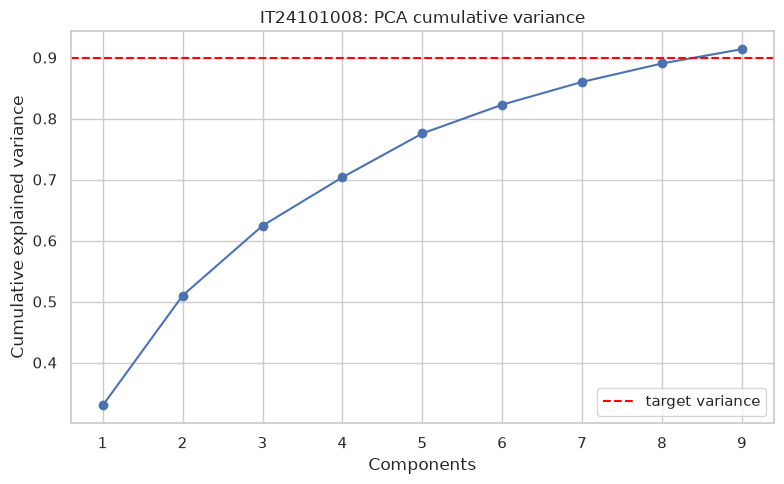

In [10]:
df_fe = df_enc.copy()
eps = 1e-6
df_fe['ctg_risk_index'] = (
    df_fe['abnormal_short_term_variability']
    + df_fe['percentage_of_time_with_abnormal_long_term_variability']
    + 10 * df_fe['prolongued_decelerations']
    + 5 * df_fe['severe_decelerations']
)
df_fe['accel_minus_decel'] = df_fe['accelerations'] - (
    df_fe['light_decelerations'] + df_fe['severe_decelerations'] + df_fe['prolongued_decelerations']
)
df_fe['ltv_stv_ratio'] = df_fe['mean_value_of_long_term_variability'] / (df_fe['mean_value_of_short_term_variability'] + eps)
df_fe['hist_asymmetry'] = (df_fe['histogram_mean'] - df_fe['histogram_mode']).abs()
engineered = ['ctg_risk_index', 'accel_minus_decel', 'ltv_stv_ratio', 'hist_asymmetry']

display(df_fe[engineered].describe().T)

base_cols = [c for c in feature_cols if c != 'histogram_tendency']

X_fe_cols = base_cols + extra_enc_cols + engineered

seen = set(); X_fe_cols = [c for c in X_fe_cols if not (c in seen or seen.add(c))]

X_fe_cols = [c for c in X_fe_cols if c in df_fe.columns]

X_all = df_fe[X_fe_cols].astype(float).copy()

y_all = df_fe['fetal_health_encoded'].copy()

scaler = StandardScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X_all), columns=X_fe_cols, index=X_all.index)

print('Scaler:', type(scaler).__name__)

print('Scaled mean sample:', X_scaled.mean().head(3).round(4).to_dict())

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced')
rf.fit(X_scaled, y_all)
sfm = SelectFromModel(rf, prefit=True, max_features=12)
X_sel = sfm.transform(X_scaled)
selected_features = list(np.array(X_fe_cols)[sfm.get_support()])
imp = pd.DataFrame({'feature': X_fe_cols, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
print('SelectFromModel(RandomForest) features:')
display(imp.head(12))
X_selected_df = pd.DataFrame(X_sel, columns=selected_features, index=X_scaled.index)

pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print('PCA components for target variance:', pca.n_components_)
print('Cumulative variance:', round(pca.explained_variance_ratio_.sum(), 4))
fig, ax = plt.subplots()
cum = np.cumsum(pca.explained_variance_ratio_)
ax.plot(range(1, len(cum)+1), cum, marker='o')
ax.axhline(0.9, color='red', linestyle='--', label='target variance')
ax.set_title(f'{STUDENT_ID}: PCA cumulative variance')
ax.set_xlabel('Components'); ax.set_ylabel('Cumulative explained variance')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '04_pca_cumulative_variance.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Engineered CTG features + selection remove redundancy; PCA/SVD compress correlated signal.


## 9. Export processed dataset


In [11]:
processed = df_fe[X_fe_cols + [TARGET, 'fetal_health_encoded']].copy()
out_path = OUT_DIR / f'{STUDENT_ID}_fetal_health_processed.csv'
processed.to_csv(out_path, index=False)
print('Saved:', out_path)
print('Processed shape:', processed.shape)
display(processed.head())


Saved: /home/neon-cultivator/us2/project-aiml/results/outputs/IT24101008_fetal_health_processed.csv
Processed shape: (2113, 27)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_mean,histogram_median,histogram_variance,histogram_tendency_ord,ctg_risk_index,accel_minus_decel,ltv_stv_ratio,hist_asymmetry,fetal_health,fetal_health_encoded
0,120.0,0.000000,0.0,0.000,0.000000,0.0,0.0,73.0,0.5,27.5,...,137.0,121.0,4.060443,2.0,100.5,0.000000,4.799990,17.0,2.0,1
1,132.0,0.005982,0.0,0.006,0.002996,0.0,0.0,17.0,2.1,0.0,...,136.0,140.0,2.564949,1.0,17.0,0.002987,4.952379,5.0,1.0,0
2,133.0,0.002996,0.0,0.008,0.002996,0.0,0.0,16.0,2.1,0.0,...,135.0,138.0,2.639057,1.0,16.0,0.000000,6.380949,6.0,1.0,0
3,134.0,0.002996,0.0,0.008,0.002996,0.0,0.0,16.0,2.4,0.0,...,134.0,137.0,2.639057,2.0,16.0,0.000000,8.374997,3.0,1.0,0
4,132.0,0.006976,0.0,0.008,0.000000,0.0,0.0,16.0,2.4,0.0,...,136.0,138.0,2.484907,2.0,16.0,0.006976,8.291663,1.0,1.0,0


## 10. Bridge — stratified split + baseline (no leakage)

Fit imputer/scaler on **train only**. Baseline Logistic Regression with `class_weight='balanced'`.


Train: (1690, 25) Test: (423, 25)
Accuracy=0.8629 | Macro-F1=0.7839
              precision    recall  f1-score   support

      Normal       0.97      0.87      0.92       330
     Suspect       0.58      0.79      0.67        58
Pathological       0.65      0.91      0.76        35

    accuracy                           0.86       423
   macro avg       0.74      0.86      0.78       423
weighted avg       0.89      0.86      0.87       423



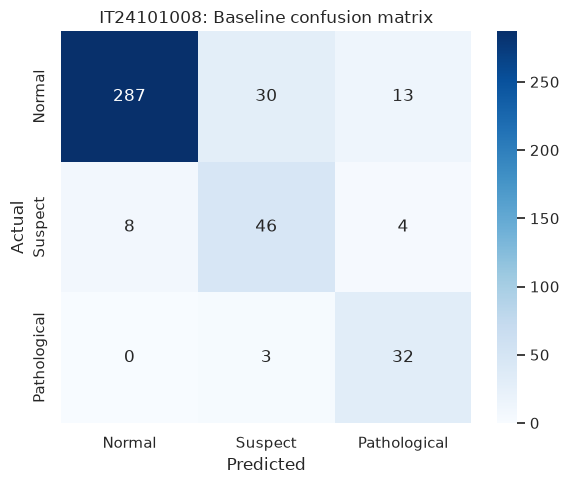

In [12]:
X = df_fe[X_fe_cols].astype(float).copy()
y = df_fe['fetal_health_encoded'].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, 'Test:', X_test.shape)
pipe_imputer = SimpleImputer(strategy='median')
pipe_scaler = StandardScaler()
X_train_s = pipe_scaler.fit_transform(pipe_imputer.fit_transform(X_train))
X_test_s = pipe_scaler.transform(pipe_imputer.transform(X_test))
baseline = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
baseline.fit(X_train_s, y_train)
y_pred = baseline.predict(X_test_s)
print(f"Accuracy={accuracy_score(y_test, y_pred):.4f} | Macro-F1={f1_score(y_test, y_pred, average='macro'):.4f}")
print(classification_report(y_test, y_pred, target_names=[CLASS_MAP[float(c)] for c in label_encoder.classes_]))
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
labels = [CLASS_MAP[float(c)] for c in label_encoder.classes_]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title(f'{STUDENT_ID}: Baseline confusion matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
fig.tight_layout()
fig.savefig(FIG_DIR / '05_baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
